# Generation and post-analysis in ACTG320 dataset 

#### Associated publication
Reference: https://www.nejm.org/doi/full/10.1056/NEJM199709113371101

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tableone import TableOne
import torch
from sksurv.nonparametric import kaplan_meier_estimator
import os
import sys
from pathlib import Path
module_path = Path.cwd().parent / 'utils'
sys.path.append(str(module_path))
import data_processing, visualization

module_path = Path.cwd().parent / 'execute'
sys.path.append(str(module_path))

from synthcity.metrics.plots import plot_tsne
from synthcity.metrics.eval import Metrics
from synthcity.metrics.scores import ScoreEvaluator
from synthcity.plugins.core.dataloader import SurvivalAnalysisDataLoader
from synthcity.utils.reproducibility import clear_cache, enable_reproducible_results

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


## 1. Original data loading, analysis and visualization

### 1.1. Experiment setting - links to data

In [2]:
dataset_name = "ACTG320"
current_path = os.getcwd()  # Get current working directory
parent_path = os.path.dirname(current_path)
data_file_control= parent_path + "/dataset/" + dataset_name + "/data_control.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
data_file_treated= parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

# If the dataset has no missing data, leave the "miss_file" variable empty
m_perc = 10
mask = 1
miss_file = parent_path + "/dataset/" + dataset_name + "/Missing{}_{}.csv".format(m_perc, mask)
true_miss_file = None

### 1.2. Loading, feature analysis, and visualization of original data: control vs treated group

In [3]:
control_fnames = ['time', 'censor'] + pd.read_csv(feat_types_file_control)["name"].to_list()[1:]
control = pd.read_csv(data_file_control, header=None, names=control_fnames)
print(control.head())

   time  censor  strat2  sex  raceth  ivdrug  karnof    cd4  priorzdv  age
0   189       0       1    1       1       0     100  169.0      39.0   34
1   287       0       1    2       2       0      90  149.5      15.0   34
2   199       0       1    1       1       0      90   46.0      53.0   48
3   270       0       1    1       2       0     100   54.5       6.0   51
4   276       0       1    1       1       0     100   95.0       7.0   34


In [4]:
# Load and transform control data
data_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _ = data_processing.read_data(data_file_control, 
                                                                                                             feat_types_file_control, 
                                                                                                             miss_file, true_miss_file)

In [5]:
# Load and transform control data
df_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _ = data_processing.read_data(data_file_control, feat_types_file_control, miss_file, true_miss_file)
data_init_control_encoded = torch.from_numpy(df_init_control_encoded.values)
data_init_control = data_processing.discrete_variables_transformation(data_init_control_encoded, feat_types_dict)

# Load and transform treated data
df_init_treated_encoded, _, _, _, _ = data_processing.read_data(data_file_treated, feat_types_file_treated, miss_file, true_miss_file)
data_init_treated_encoded = torch.from_numpy(df_init_treated_encoded.values)
data_init_treated = data_processing.discrete_variables_transformation(data_init_treated_encoded, feat_types_dict)

In [6]:
# Format data in dataframe
df_init_treated = pd.DataFrame(data_init_treated.numpy(), columns=control_fnames)
df_init_control = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)

# Update the data
df_init_treated["treatment"] = 1
df_init_control["treatment"] = 0
df_init = pd.concat([df_init_control, df_init_treated], ignore_index=True)

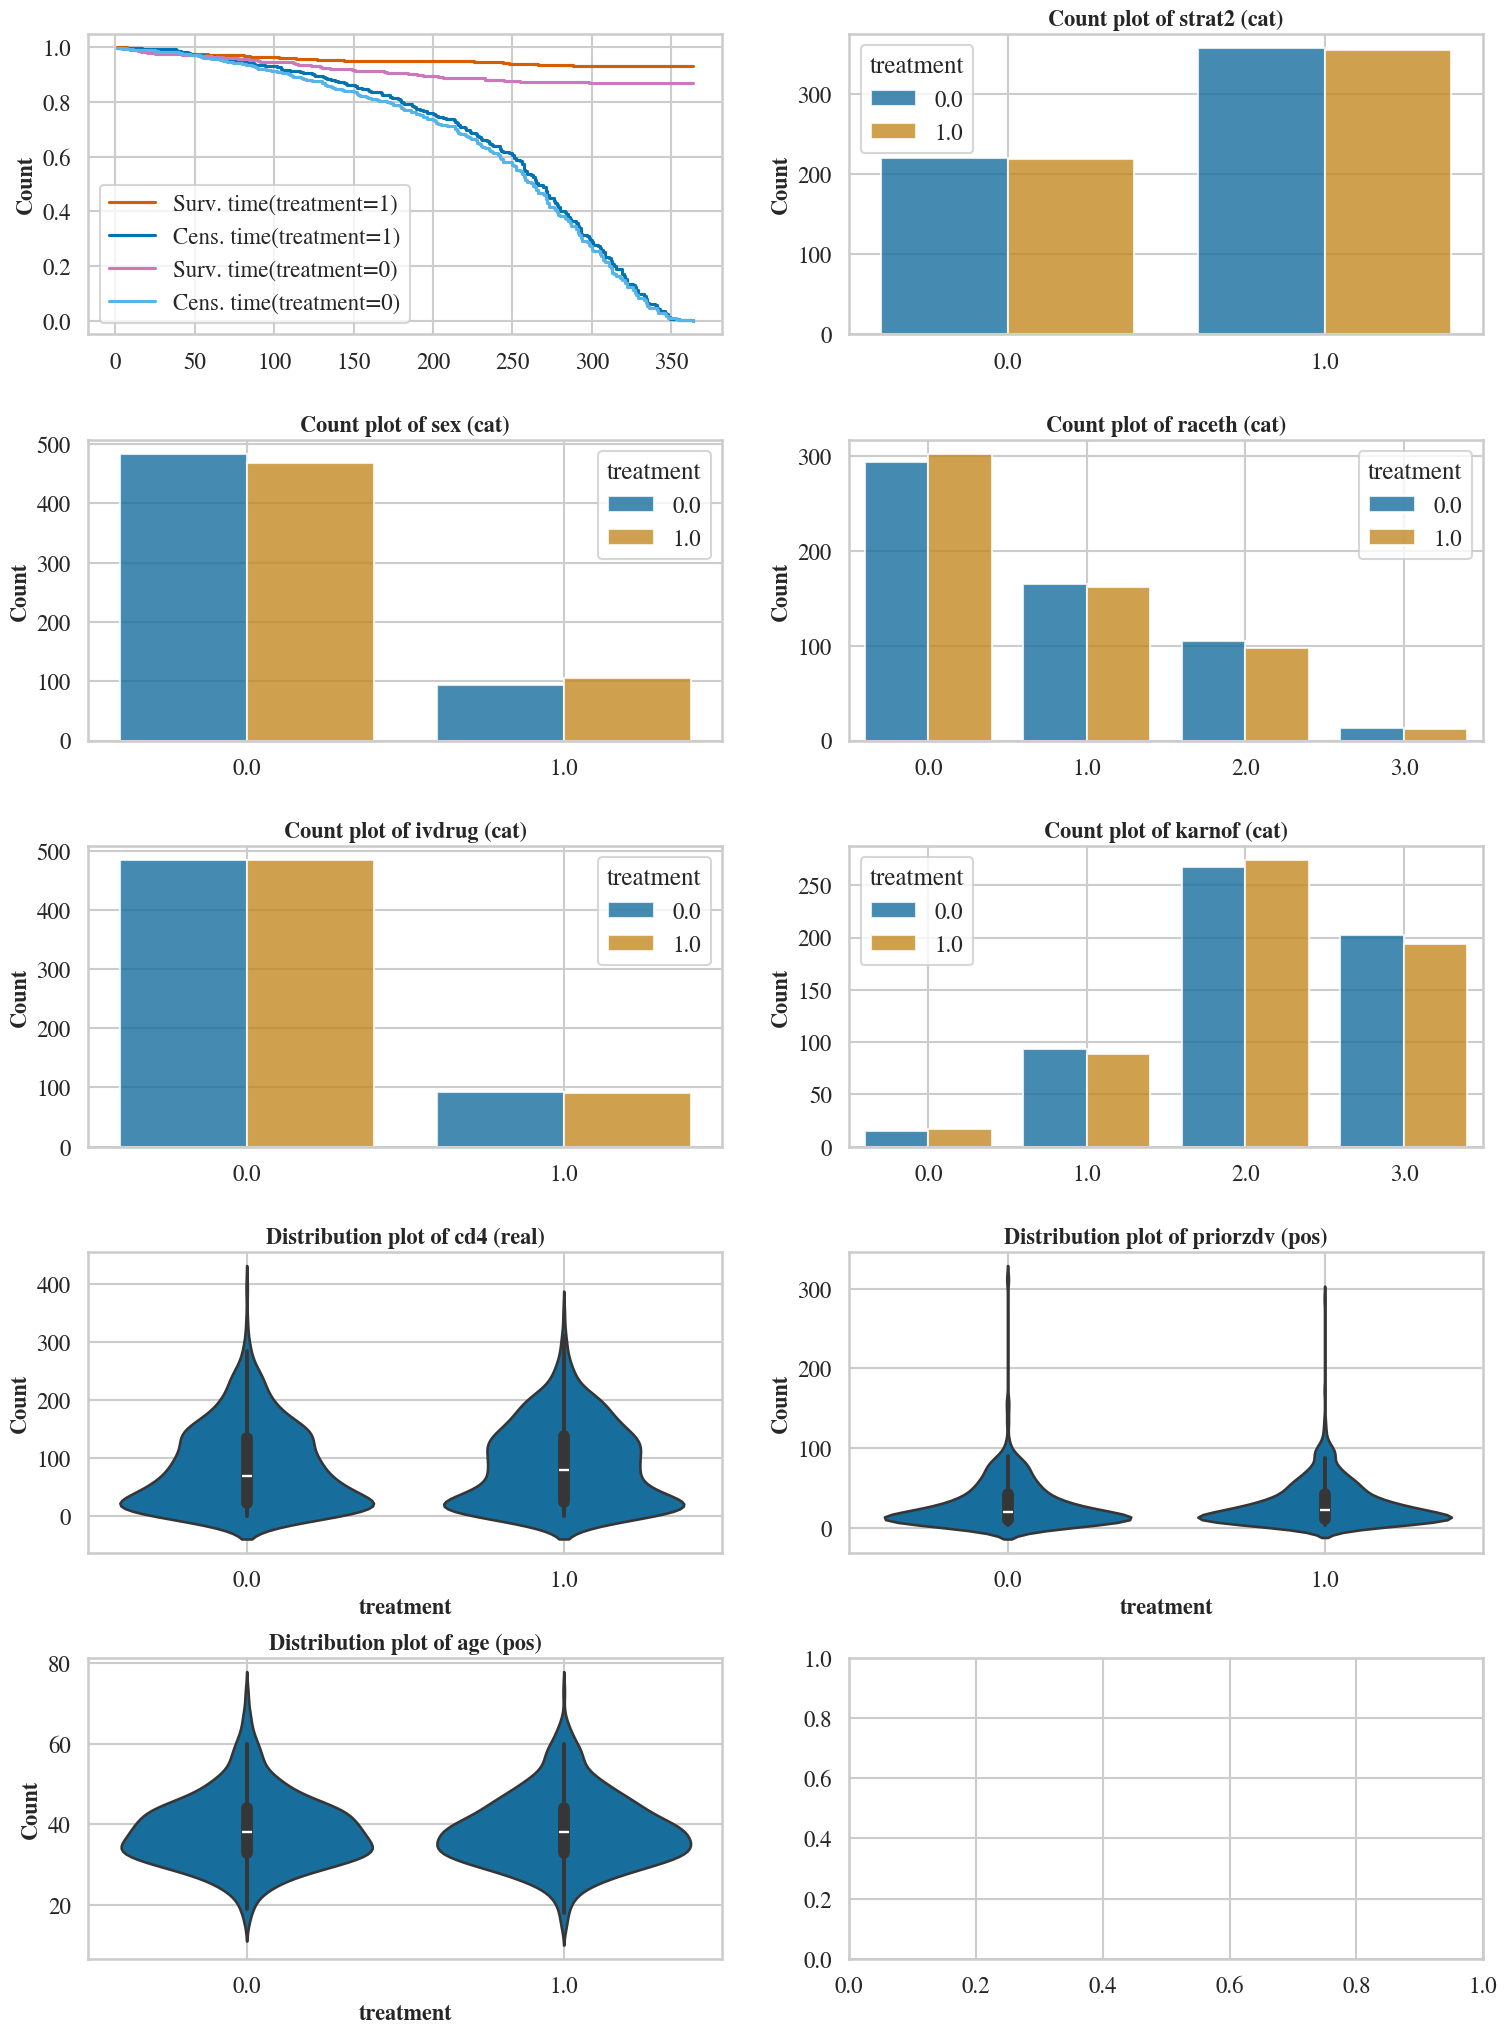

In [7]:
# TODO: Refactor
feat_types_dict_all = feat_types_dict.copy()
feat_types_dict_all.append({'name': 'treatment', 'type': 'cat', 'dim': '1', 'nclass': '2'})
visualization.plot_data(df_init.to_numpy(), feat_types_dict_all, feat_comparison_name='treatment')

In [8]:
categorical = ['censor','strat2', 'sex', 'raceth', 'ivdrug', 'karnof','treatment']
continuous = ['time', 'cd4', 'priorzdv', 'age']
nonnormal = ['time', 'cd4', 'priorzdv']

table1 = TableOne(df_init, categorical=categorical, continuous=continuous, 
                  groupby='treatment', nonnormal=nonnormal, pval=True)
print(table1)

                             Grouped by treatment                                                                       
                                          Missing              Overall                    0                    1 P-Value
n                                                                 1151                  577                  574        
time, median [Q1,Q3]                            0  257.0 [174.0,300.0]  251.0 [158.0,298.0]  263.0 [187.0,305.0]   0.014
censor, n (%)            0.0                               1055 (91.7)           514 (89.1)           541 (94.3)   0.002
                         1.0                                  96 (8.3)            63 (10.9)             33 (5.7)        
strat2, n (%)            0.0                                439 (38.1)           220 (38.1)           219 (38.2)   1.000
                         1.0                                712 (61.9)           357 (61.9)           355 (61.8)        
sex, n (%)               0.0    

## 2. Training and generation from the generative model

Possible generative models: HI-VAE (our), survival_gan, survival_ctgan, survival_nflow, survae (synthcity)

In [9]:
import surv_hivae

# the datasets used for training is data_init_control
n_generated_dataset = 100

In [10]:
# data_gen_control = surv_hivae.run(df_init_control_encoded,
#                                   miss_mask_control, 
#                                   true_miss_mask_control,
#                                   feat_types_dict,
#                                   n_generated_dataset, params={"n_layers_surv_piecewise": 1,
#                                                                "n_intervals": 10})

feat_types_dict_ext = feat_types_dict.copy()
for i in range(len(feat_types_dict)):
    if feat_types_dict_ext[i]['name'] == "survcens":
        feat_types_dict_ext[i]["type"] = 'surv_piecewise'
data_gen_control = surv_hivae.run(df_init_control_encoded,
                                  miss_mask_control, 
                                  true_miss_mask_control,
                                  feat_types_dict_ext,
                                  n_generated_dataset,
                                  params={"n_layers_surv_piecewise": 1, 
                                          "n_intervals": 10},
                                #   params=best_params_dict["HI-VAE_weibull"],
                                  epochs=10000, diffusion=True)

Epoch: [ 0]  time: 0.0801, ELBO_train: -20.89819495, KL_z: 1.29652391, KL_s: 0.07243683, reconstruction loss: -19.52923421
Epoch: [100]  time: 2.8398, ELBO_train: -17.24378141, KL_z: 0.73583609, KL_s: 0.06738025, reconstruction loss: -16.44056507
Epoch: [200]  time: 6.0822, ELBO_train: -17.23232746, KL_z: 0.87177793, KL_s: 0.04248721, reconstruction loss: -16.31806232
Epoch: [300]  time: 9.5395, ELBO_train: -17.08713818, KL_z: 1.06320579, KL_s: 0.04493902, reconstruction loss: -15.97899337
Epoch: [400]  time: 13.2215, ELBO_train: -16.95153427, KL_z: 1.31505732, KL_s: 0.05221152, reconstruction loss: -15.58426543
Epoch: [500]  time: 16.5472, ELBO_train: -16.93666744, KL_z: 1.42112583, KL_s: 0.05248057, reconstruction loss: -15.46306105
Epoch: [600]  time: 20.0446, ELBO_train: -17.00372060, KL_z: 1.55380261, KL_s: 0.04875235, reconstruction loss: -15.40116565
Early stopping at epoch 600.
Training finished.
  [diffusion] train/val split: 462 / 115 latent rows
  [diffusion] epoch   0  trai

## 3. Analyze the generated data

### 3.1. Statistical analysis: one generated control group vs. initial control data

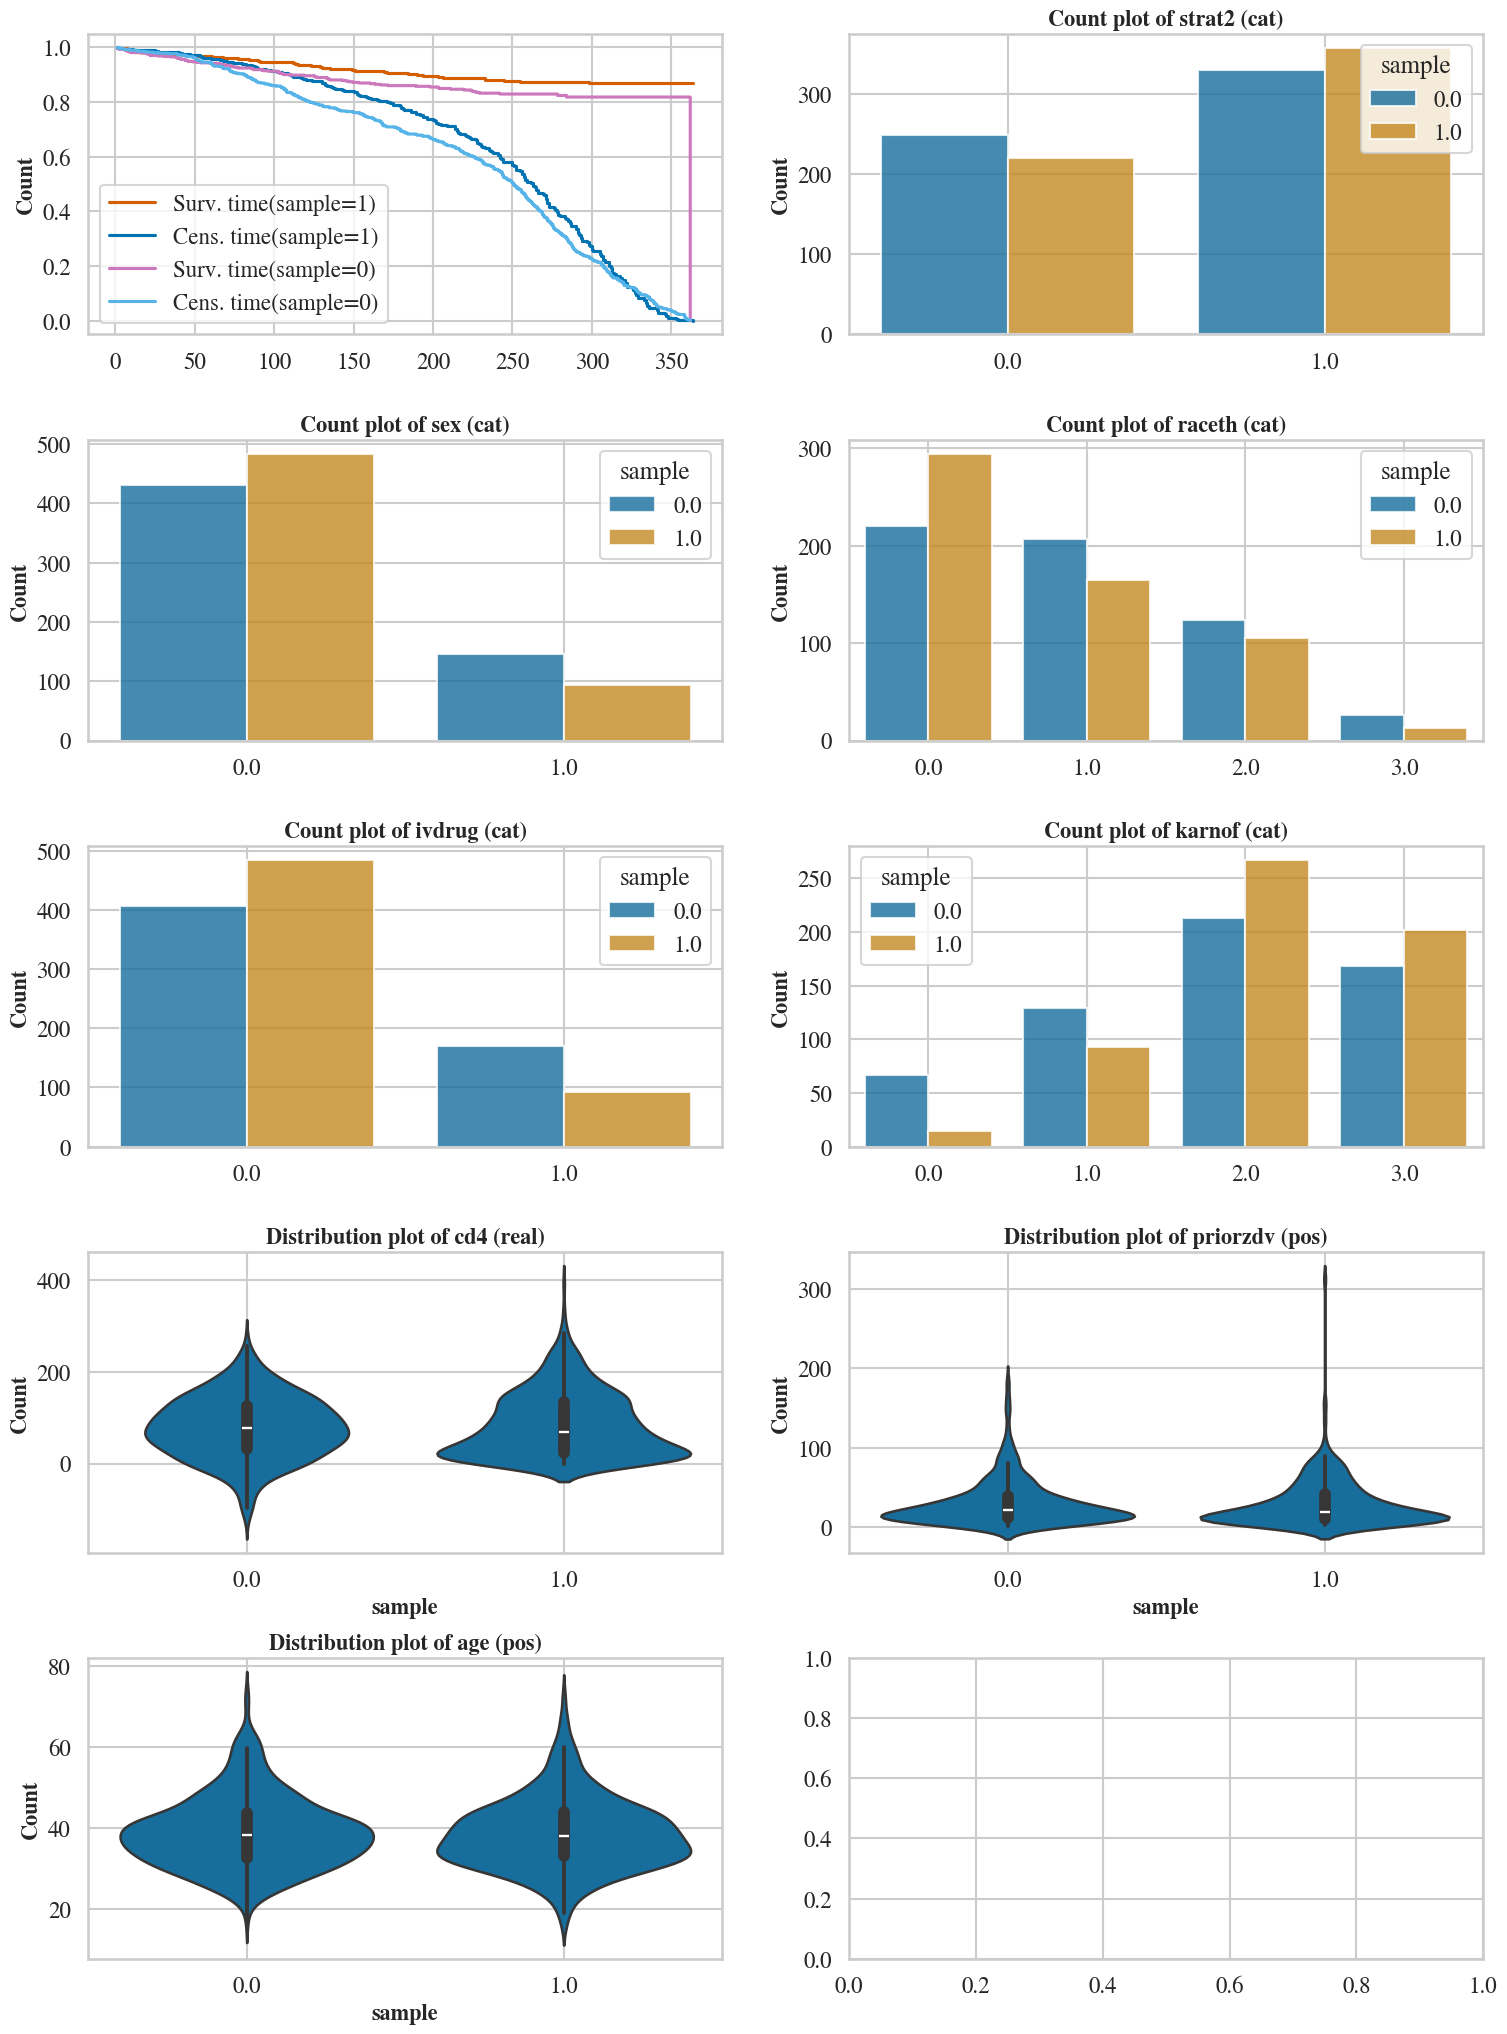

In [11]:
df_init_control_ext = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)
df_init_control_ext['sample'] = 1

sel_idx = 2
df_gen_control_ext_sel = pd.DataFrame(data_gen_control[sel_idx].numpy(), columns=control_fnames)
df_gen_control_ext_sel['sample'] = 0

feat_types_dict_ext = feat_types_dict.copy()
feat_types_dict_ext.append({'name': 'sample', 'type': 'cat', 'dim': '1', 'nclass': '2'})
df_control_sel = pd.concat([df_init_control_ext, df_gen_control_ext_sel], ignore_index=True)
visualization.plot_data(df_control_sel.to_numpy(), feat_types_dict_ext, feat_comparison_name = 'sample')

In [12]:
categorical = ['censor','strat2', 'sex', 'raceth', 'ivdrug', 'karnof','sample']
continuous = ['time', 'cd4', 'priorzdv', 'age']
nonnormal = ['time', 'cd4', 'priorzdv']
table1 = TableOne(df_control_sel, categorical=categorical, continuous=continuous, groupby='sample', nonnormal=nonnormal, pval=True)
print(table1)

                             Grouped by sample                                                                       
                                       Missing              Overall                    0                    1 P-Value
n                                                              1154                  577                  577        
time, median [Q1,Q3]                         0  241.0 [132.0,290.9]  226.6 [110.5,283.8]  251.0 [158.0,298.0]  <0.001
censor, n (%)            0.0                            1005 (87.1)           491 (85.1)           514 (89.1)   0.053
                         1.0                             149 (12.9)            86 (14.9)            63 (10.9)        
strat2, n (%)            0.0                             468 (40.6)           248 (43.0)           220 (38.1)   0.105
                         1.0                             686 (59.4)           329 (57.0)           357 (61.9)        
sex, n (%)               0.0                            

In [13]:
synthcity_dataloader_init = SurvivalAnalysisDataLoader(df_init_control, target_column = "censor", time_to_event_column = "time")
synthcity_dataloader_syn = SurvivalAnalysisDataLoader(df_gen_control_ext_sel, target_column = "censor", time_to_event_column = "time")

### 3.2. Statistical analysis: one generated control group vs. initial treated data

In [14]:
list_df_gen_control = []
for j in range(n_generated_dataset):
    df_gen_control_j = pd.DataFrame(data_gen_control[j].numpy(), columns=control_fnames)
    df_gen_control_j['treatment'] = 0
    list_df_gen_control.append(df_gen_control_j)

In [15]:
# Set display options
pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # Prevent line wrapping
pd.set_option('display.max_colwidth', None)  # Show full content of each column

metrics = {
    'sanity': ['nearest_syn_neighbor_distance'],
    'stats': ['jensenshannon_dist', 'ks_test', 'survival_km_distance'],
    'performance': ['feat_rank_distance'],
    'detection': ['detection_xgb'],
    'privacy': ['k-map', 'distinct l-diversity', 'identifiability_score']
}
scores = ScoreEvaluator()
for j in range(n_generated_dataset):
    enable_reproducible_results(j)
    clear_cache()

    synthcity_dataloader_syn = SurvivalAnalysisDataLoader(list_df_gen_control[j], 
                                       target_column = "censor", 
                                       time_to_event_column = "time")

    evaluation = Metrics().evaluate(X_gt=synthcity_dataloader_init, # can be dataloaders or dataframes
                                    X_syn=synthcity_dataloader_syn, 
                                    reduction='mean', # default mean
                                    n_histogram_bins=10, # default 10
                                    metrics=metrics, # all metrics
                                    task_type='survival_analysis', 
                                    use_cache=True)

    mean_score = evaluation["mean"].to_dict()
    errors = evaluation["errors"].to_dict()
    duration = evaluation["durations"].to_dict()
    direction = evaluation["direction"].to_dict()

    for key in mean_score:
        scores.add(key, mean_score[key], errors[key], duration[key], direction[key])

synthcity_score = scores.to_dataframe()
synthcity_score

,min,max,mean,stddev,median,iqr,rounds,errors,durations,direction
sanity.nearest_syn_neighbor_distance.mean,0.077916,0.150634,0.105307,0.014933,0.103739,0.020176,100,0,0.00,minimize
stats.jensenshannon_dist.marginal,0.013094,0.017393,0.015229,0.000862,0.015261,0.001120,100,0,0.02,minimize
stats.ks_test.marginal,0.889239,0.916969,0.904071,0.005063,0.904049,0.006775,100,0,0.00,maximize
stats.survival_km_distance.optimism,-0.093555,-0.011491,-0.058740,0.012534,-0.058178,0.014775,100,0,0.43,minimize
stats.survival_km_distance.abs_optimism,0.012361,0.093669,0.059061,0.012446,0.058302,0.014761,100,0,0.43,minimize
stats.survival_km_distance.sightedness,0.005495,0.015163,0.006779,0.002085,0.005845,0.001537,100,0,0.43,minimize
detection.detection_xgb.mean,0.853117,0.906466,0.882738,0.010772,0.883116,0.015286,100,0,0.07,minimize
privacy.k-map.score,1.000000,7.000000,3.260000,1.425623,3.000000,2.000000,100,0,0.02,maximize
privacy.distinct l-diversity.gt,2.000000,2.000000,2.000000,0.000000,2.000000,0.000000,100,0,0.04,maximize
privacy.distinct l-diversity.syn,1.000000,24.000000,6.920000,4.932910,6.000000,7.250000,100,0,0.04,maximize
